In [5]:
# 02_conductance_dynamics.ipynb
# Goal: compare AMPA conductance buildup in non-overlap vs overlap burst cases.

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Let this notebook import from src/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.inputs import (
    make_burst_sequence,
    burst_overlap_duration,
    g_AMPA_vector,
)

from src.dendrite import (
    simulate_dendrite,
    score_detection,
    plot_input_raster,
    plot_voltage_traces,
    plot_ampa_conductances,
)


# Shared setup
n_segments = 12
sequence_segments = [5, 6, 7, 8]

T = 90.0
dt = 0.02

G_NMDA = 20.0
G_KIR = 20.0
G_ax = 1.0

start_time = 10.0
weight = 1.0

burst_len = 3
isi_ms = 2.0


def get_ampa_matrix(times, n_segments, events):
    """Return AMPA conductance over time for every segment."""
    G = np.zeros((len(times), n_segments))

    for i, t in enumerate(times):
        G[i, :] = g_AMPA_vector(
            t=float(t),
            n_segments=n_segments,
            ampa_events=events,
        )

    return G


def plot_selected_ampa(times, G_ampa, segments, title):
    """Plot AMPA conductance for selected segments."""
    plt.figure(figsize=(8, 4))

    for seg in segments:
        plt.plot(times, G_ampa[:, seg], label=f"segment {seg}")

    plt.xlabel("time (ms)")
    plt.ylabel("AMPA conductance")
    plt.title(title)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def summarize_ampa(times, G_ampa, segments, t_start=8, t_end=35):
    """Print simple AMPA metrics for each segment."""
    mask = (times >= t_start) & (times <= t_end)

    print("AMPA summary")
    print("-" * 60)

    for seg in segments:
        g = G_ampa[mask, seg]
        t = times[mask]

        peak_g = float(np.max(g))
        peak_t = float(t[np.argmax(g)])

        # np.trapezoid is the newer version of np.trapz
        area_g = float(np.trapezoid(g, t))

        print(
            f"segment {seg}: "
            f"peak = {peak_g:.3f}, "
            f"peak time = {peak_t:.3f} ms, "
            f"area = {area_g:.3f}"
        )

In [6]:
# Build two cases:
# 1. non-overlap burst
# 2. failure case with 3.5 ms overlap

nonoverlap_step_ms = 8.0

target_overlap_ms = 3.5
burst_span_ms = (burst_len - 1) * isi_ms
failure_step_ms = burst_span_ms - target_overlap_ms

print("burst span:", burst_span_ms, "ms")
print("non-overlap onset step:", nonoverlap_step_ms, "ms")
print("failure target overlap:", target_overlap_ms, "ms")
print("failure onset step:", failure_step_ms, "ms")


nonoverlap_events, nonoverlap_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=nonoverlap_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)

failure_events, failure_raster = make_burst_sequence(
    sequence_segments=sequence_segments,
    start_time=start_time,
    onset_step_ms=failure_step_ms,
    burst_len=burst_len,
    isi_ms=isi_ms,
    weight=weight,
)


times_non, V_non = simulate_dendrite(
    n_segments=n_segments,
    T=T,
    dt=dt,
    G_NMDA=G_NMDA,
    G_KIR=G_KIR,
    G_ax=G_ax,
    ampa_events=nonoverlap_events,
)

times_fail, V_fail = simulate_dendrite(
    n_segments=n_segments,
    T=T,
    dt=dt,
    G_NMDA=G_NMDA,
    G_KIR=G_KIR,
    G_ax=G_ax,
    ampa_events=failure_events,
)


G_ampa_non = get_ampa_matrix(
    times_non,
    n_segments=n_segments,
    events=nonoverlap_events,
)

G_ampa_fail = get_ampa_matrix(
    times_fail,
    n_segments=n_segments,
    events=failure_events,
)

burst span: 4.0 ms
non-overlap onset step: 8.0 ms
failure target overlap: 3.5 ms
failure onset step: 0.5 ms


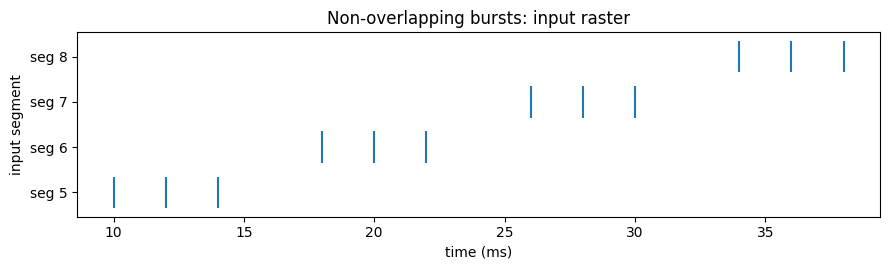

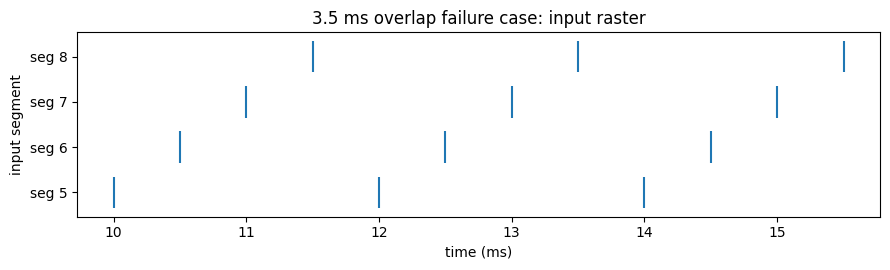

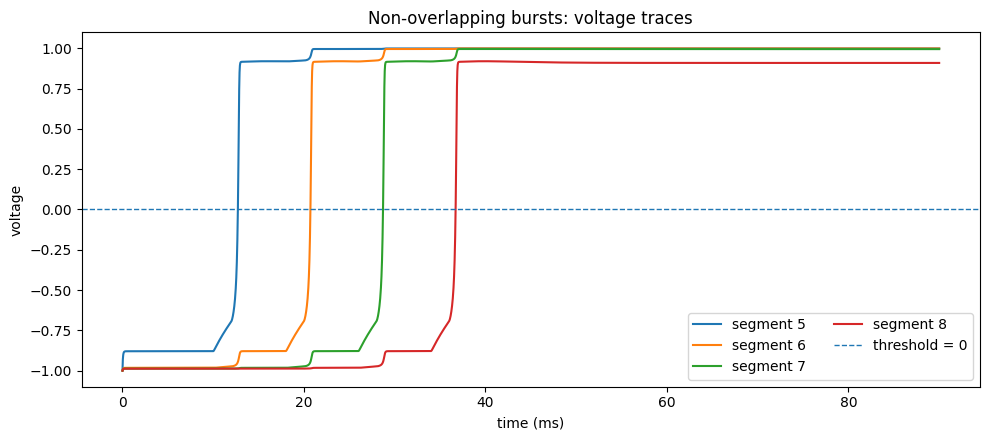

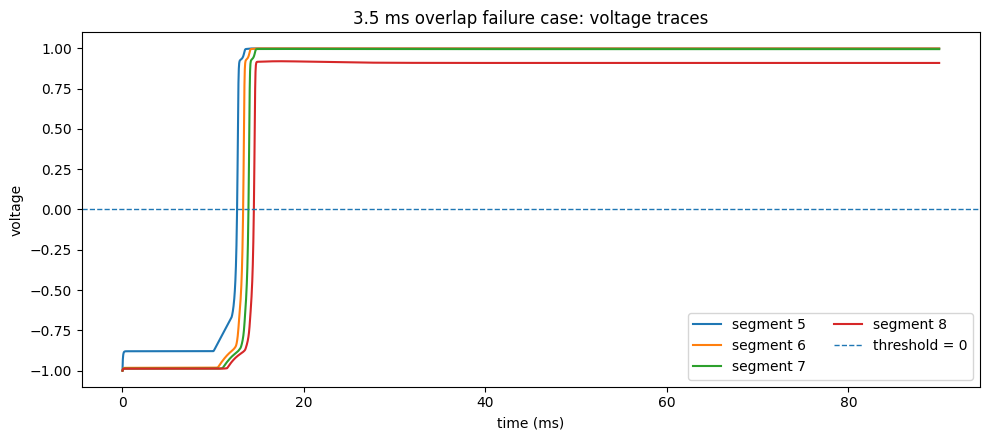

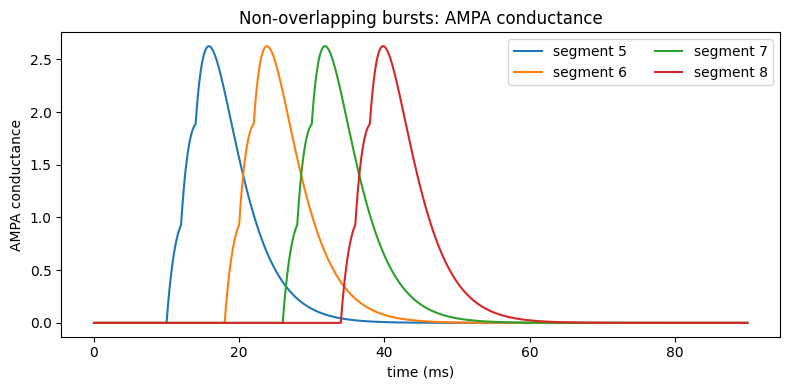

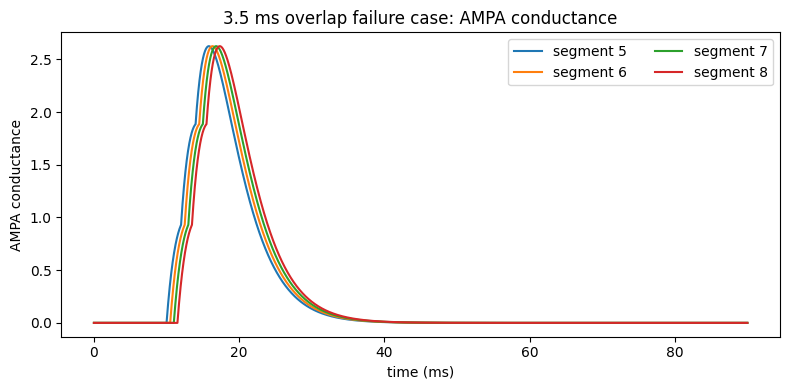

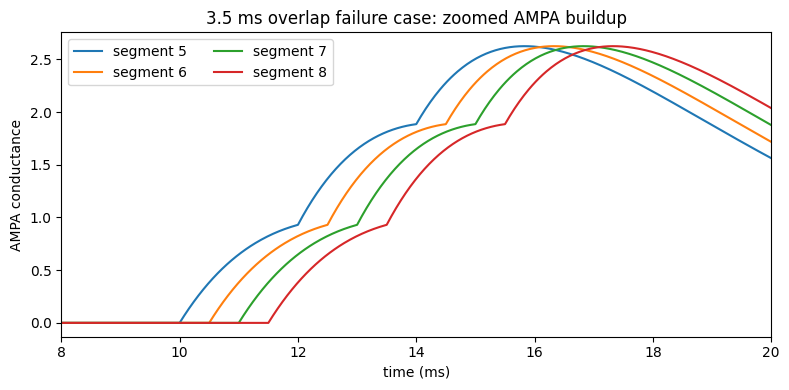

Non-overlapping bursts
AMPA summary
------------------------------------------------------------
segment 5: peak = 2.626, peak time = 15.820 ms, area = 24.459
segment 6: peak = 2.626, peak time = 23.820 ms, area = 24.403
segment 7: peak = 2.626, peak time = 31.820 ms, area = 23.840
segment 8: peak = 2.626, peak time = 39.820 ms, area = 19.232

3.5 ms overlap failure case
AMPA summary
------------------------------------------------------------
segment 5: peak = 2.626, peak time = 15.820 ms, area = 24.459
segment 6: peak = 2.626, peak time = 16.320 ms, area = 24.458
segment 7: peak = 2.626, peak time = 16.820 ms, area = 24.457
segment 8: peak = 2.626, peak time = 17.320 ms, area = 24.456


In [ ]:
# Visualize inputs

plot_input_raster(
    nonoverlap_raster,
    title="Non-overlapping bursts: input raster",
)

plot_input_raster(
    failure_raster,
    title="3.5 ms overlap failure case: input raster",
)


# Voltage traces

plot_voltage_traces(
    times_non,
    V_non,
    segments_to_plot=sequence_segments,
    title="Non-overlapping bursts: voltage traces",
)

plot_voltage_traces(
    times_fail,
    V_fail,
    segments_to_plot=sequence_segments,
    title="3.5 ms overlap failure case: voltage traces",
)


# AMPA conductance traces

plot_selected_ampa(
    times_non,
    G_ampa_non,
    sequence_segments,
    title="Non-overlapping bursts: AMPA conductance",
)

plot_selected_ampa(
    times_fail,
    G_ampa_fail,
    sequence_segments,
    title="3.5 ms overlap failure case: AMPA conductance",
)


# Zoomed AMPA comparison

plt.figure(figsize=(8, 4))

for seg in sequence_segments:
    plt.plot(
        times_fail,
        G_ampa_fail[:, seg],
        label=f"segment {seg}",
    )

plt.xlim(8, 20)
plt.xlabel("time (ms)")
plt.ylabel("AMPA conductance")
plt.title("3.5 ms overlap failure case: zoomed AMPA buildup")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


# Print simple AMPA metrics

print("Non-overlapping bursts")
summarize_ampa(
    times_non,
    G_ampa_non,
    sequence_segments,
    t_start=8,
    t_end=55,
)

print()
print("3.5 ms overlap failure case")
summarize_ampa(
    times_fail,
    G_ampa_fail,
    sequence_segments,
    t_start=8,
    t_end=55,
)